In [2]:
import sys
sys.path.insert(0, '../Week-5-6-7-8')

import json
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR, NuSVR

from helpers.modeling import identify_column_types, create_preprocessor
from uncertainty import run_conformal, calibration_table, prepare_data_group

with open('../Week-5-6-7-8/results.json', 'r') as f:
    results = json.load(f)

df = pd.read_csv("../Datasets/processed/UHPC_dataset/semantic_recoding_features_50_with_publications.csv")

In [3]:
target_col = 'cs_28d'

# Group-aware split: no publication bleeds across train / val / test
X_train, X_val, X_test, y_train, y_val, y_test = prepare_data_group(
    df, target_col, group_col='paper_reference'
)

pub_train = df.loc[X_train.index, 'paper_reference']
pub_test = df.loc[X_test.index, 'paper_reference']
pub_val  = df.loc[X_val.index,  'paper_reference']

print(f"Train size : {X_train.shape[0]}  ({pub_train.nunique()} publications)")
print(f"Val size   : {X_val.shape[0]}  ({pub_val.nunique()} publications)")
print(f"Test size  : {X_test.shape[0]}  ({pub_test.nunique()} publications)")

numerical_cols, one_hot_columns, k_fold_columns = identify_column_types(X_train)
preprocessor = create_preprocessor(numerical_cols, one_hot_columns, k_fold_columns,
                                   handle_unknown='ignore')
print(f"\nEncoded training shape: {preprocessor.fit_transform(X_train, y_train).shape}")

Train size : 1461  (115 publications)
Val size   : 329  (25 publications)
Test size  : 283  (25 publications)

Encoded training shape: (1461, 69)


In [4]:
pipeline_knn, train_knn, test_knn, q_knn, intervals_knn, calibration_knn = run_conformal(
    KNeighborsRegressor, 'knn', results, 'recoded_50', preprocessor,
    X_train, y_train, X_val, y_val, X_test, y_test, pub_test
)
print(f"Train: {train_knn}")
print(f"Test:  {test_knn}")
print(f"Conformal q (90%): {q_knn:.2f}")
calibration_knn

c:\Users\shoai\anaconda3\envs\aicome\Lib\site-packages\threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Train: {'RMSE': np.float64(6.243271283688685), 'MAE': 3.389420817167268, 'R2': 0.9637562073070807, 'Correlation': np.float64(0.981812803805088), 'Mean_Residual': np.float64(-0.23870522813817646), 'N': 1461}
Test:  {'RMSE': np.float64(23.137476407010737), 'MAE': 17.70780930325002, 'R2': 0.4061590729660447, 'Correlation': np.float64(0.7250168541847408), 'Mean_Residual': np.float64(-7.213957733039643), 'N': 283}
Conformal q (90%): 74.73


,publication,n_rows,mean_true,mean_prediction,coverage,interval_width,mean_residual,mean_distance
0,Ref-107-Research,16,109.031250,111.399802,1.0,149.458979,7.430507,14.967162
1,Ref-11-Research,4,127.750000,116.617613,1.0,149.458979,11.132387,9.840544
2,Ref-113-Research,5,165.055660,169.586402,1.0,149.458979,7.784647,5.867932
3,Ref-114-Research,5,208.804000,193.031941,1.0,149.458979,16.179121,5.939905
4,Ref-116-Research,36,152.627778,155.138888,1.0,149.458979,4.470121,3.928529
5,Ref-117-Research,5,113.000000,116.676618,1.0,149.458979,14.086741,17.614662
6,Ref-121-Research,80,165.075000,183.562780,1.0,149.458979,23.299449,8.685023
7,Ref-126-Research,5,114.600000,144.498122,1.0,149.458979,29.898122,5.734700
8,Ref-127-Research,3,201.200000,153.248551,1.0,149.458979,47.951449,4.686152
9,Ref-128-Research,3,201.266667,193.262433,1.0,149.458979,8.004233,3.340128


In [5]:
pipeline_svr, train_svr, test_svr, q_svr, intervals_svr, calibration_svr = run_conformal(
    SVR, 'svr', results, 'recoded_50', preprocessor,
    X_train, y_train, X_val, y_val, X_test, y_test, pub_test
)
print(f"Train: {train_svr}")
print(f"Test:  {test_svr}")
print(f"Conformal q (90%): {q_svr:.2f}")
calibration_svr

Train: {'RMSE': np.float64(10.483059112202113), 'MAE': 5.570381341376773, 'R2': 0.8978154364447879, 'Correlation': np.float64(0.9475834480506515), 'Mean_Residual': np.float64(-0.32119896336981113), 'N': 1461}
Test:  {'RMSE': np.float64(27.105514484481848), 'MAE': 20.688187874259086, 'R2': 0.18500779004265167, 'Correlation': np.float64(0.6200850506304878), 'Mean_Residual': np.float64(-4.746338802667876), 'N': 283}
Conformal q (90%): 91.47


,publication,n_rows,mean_true,mean_prediction,coverage,interval_width,mean_residual,mean_distance
0,Ref-107-Research,16,109.031250,123.347043,1.0,182.933685,20.176917,6.605913
1,Ref-11-Research,4,127.750000,123.718520,1.0,182.933685,5.635556,3.669464
2,Ref-113-Research,5,165.055660,165.159010,1.0,182.933685,2.077831,3.134616
3,Ref-114-Research,5,208.804000,186.897382,1.0,182.933685,23.809086,2.208972
4,Ref-116-Research,36,152.627778,143.806645,1.0,182.933685,8.821133,1.931542
5,Ref-117-Research,5,113.000000,130.460250,1.0,182.933685,17.460250,8.217433
6,Ref-121-Research,80,165.075000,169.342420,1.0,182.933685,15.633432,3.890665
7,Ref-126-Research,5,114.600000,166.882459,1.0,182.933685,52.282459,2.478007
8,Ref-127-Research,3,201.200000,149.535603,1.0,182.933685,51.664397,2.086587
9,Ref-128-Research,3,201.266667,204.987363,1.0,182.933685,3.720696,2.164416


In [6]:
pipeline_nusvr, train_nusvr, test_nusvr, q_nusvr, intervals_nusvr, calibration_nusvr = run_conformal(
    NuSVR, 'nusvr', results, 'recoded_50', preprocessor,
    X_train, y_train, X_val, y_val, X_test, y_test, pub_test
)
print(f"Train: {train_nusvr}")
print(f"Test:  {test_nusvr}")
print(f"Conformal q (90%): {q_nusvr:.2f}")
calibration_nusvr

Train: {'RMSE': np.float64(8.323917277803206), 'MAE': 5.539982999468207, 'R2': 0.9355734707236965, 'Correlation': np.float64(0.967276040354125), 'Mean_Residual': np.float64(-0.13533321318177402), 'N': 1461}
Test:  {'RMSE': np.float64(26.896972866089744), 'MAE': 21.19966875932328, 'R2': 0.19750015464609283, 'Correlation': np.float64(0.6220522061221516), 'Mean_Residual': np.float64(-3.611063657661903), 'N': 283}
Conformal q (90%): 82.74


,publication,n_rows,mean_true,mean_prediction,coverage,interval_width,mean_residual,mean_distance
0,Ref-107-Research,16,109.031250,123.662466,1.0,165.486044,20.177446,6.603490
1,Ref-11-Research,4,127.750000,118.708253,1.0,165.486044,9.041747,3.656958
2,Ref-113-Research,5,165.055660,166.970795,1.0,165.486044,1.940436,3.133425
3,Ref-114-Research,5,208.804000,183.298948,1.0,165.486044,25.812854,2.199178
4,Ref-116-Research,36,152.627778,136.091171,1.0,165.486044,16.536606,1.931494
5,Ref-117-Research,5,113.000000,128.659150,1.0,165.486044,15.659150,8.213484
6,Ref-121-Research,80,165.075000,170.124062,1.0,165.486044,15.966238,3.885322
7,Ref-126-Research,5,114.600000,161.414050,1.0,165.486044,46.814050,2.476613
8,Ref-127-Research,3,201.200000,152.514507,1.0,165.486044,48.685493,2.086634
9,Ref-128-Research,3,201.266667,200.910309,1.0,165.486044,4.210404,2.164416


In [ ]:
poor_coverage_threshold = 1

poor_coverage = pd.concat([
    calibration_knn.assign(model='knn'),
    calibration_svr.assign(model='svr'),
    calibration_nusvr.assign(model='nusvr'),
])
poor_coverage = (
    poor_coverage[poor_coverage['coverage'] < poor_coverage_threshold]
    .sort_values('coverage')
    [['model', 'publication', 'n_rows', 'coverage', 'interval_width', 'mean_residual', 'mean_distance']]
    .reset_index(drop=True)
)

print(f"Publications below {poor_coverage_threshold:.0%} coverage: {poor_coverage['publication'].nunique()} unique, {len(poor_coverage)} model-publication pairs")
poor_coverage

Publications below 110% coverage: 25 unique, 75 model-publication pairs


,model,publication,n_rows,coverage,interval_width,mean_residual,mean_distance
0,nusvr,Ref-93-Research,10,0.9,165.486044,30.182130,3.072489
1,knn,Ref-107-Research,16,1.0,149.458979,7.430507,14.967162
2,knn,Ref-113-Research,5,1.0,149.458979,7.784647,5.867932
3,knn,Ref-11-Research,4,1.0,149.458979,11.132387,9.840544
4,knn,Ref-116-Research,36,1.0,149.458979,4.470121,3.928529
...,...,...,...,...,...,...,...
70,nusvr,Ref-69-Research,12,1.0,165.486044,41.090455,4.496710
71,nusvr,Ref-44-Research,4,1.0,165.486044,9.348294,3.257192
72,nusvr,Ref-71-Research,3,1.0,165.486044,14.604534,4.338622
73,nusvr,Ref-81-Research,4,1.0,165.486044,7.771659,2.256416


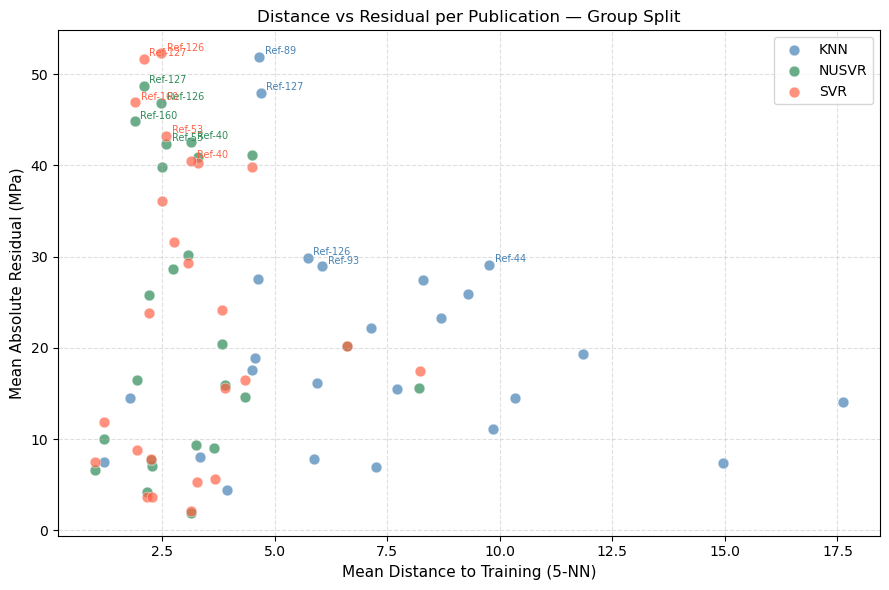

In [8]:
import matplotlib.pyplot as plt

all_cal = pd.concat([
    calibration_knn.assign(model='knn'),
    calibration_svr.assign(model='svr'),
    calibration_nusvr.assign(model='nusvr'),
], ignore_index=True)

colors = {'knn': 'steelblue', 'svr': 'tomato', 'nusvr': 'seagreen'}

fig, ax = plt.subplots(figsize=(9, 6))

for model_name, grp in all_cal.groupby('model'):
    ax.scatter(grp['mean_distance'], grp['mean_residual'],
               label=model_name.upper(), color=colors[model_name],
               alpha=0.7, edgecolors='white', linewidths=0.4, s=60)

# label outliers: top 5 by mean_residual per model
for model_name, grp in all_cal.groupby('model'):
    for _, row in grp.nlargest(5, 'mean_residual').iterrows():
        ax.annotate(row['publication'].replace('-Research', '').replace('-data', ''),
                    xy=(row['mean_distance'], row['mean_residual']),
                    fontsize=7, color=colors[model_name],
                    xytext=(4, 2), textcoords='offset points')

ax.set_xlabel('Mean Distance to Training (5-NN)', fontsize=11)
ax.set_ylabel('Mean Absolute Residual (MPa)', fontsize=11)
ax.set_title('Distance vs Residual per Publication — Group Split', fontsize=12)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [9]:
print(q_knn, q_svr, q_nusvr)

74.72948928049638 91.46684252140345 82.74302195944813
